In [1]:
from pathlib import Path

from matplotlib import pyplot as plt

import json 
import numpy as np

In [2]:
ARTIFACT_DIR = Path("../../artifacts/2023-05-S5/experiment-binary-task")

In [23]:
def load_stats(dataset, model, layer, basis_name):
    
    
    filepath = ARTIFACT_DIR / dataset / model / layer / basis_name / "stats.json"
    
    
    with open(filepath, "r") as fh:
        stats = json.load(fh)

        aurocs = np.array(stats["arr_auroc"])
        
        original_auroc = stats["original_auroc"]
        
        stats["original_auroc_corrected"] = np.max([original_auroc, 1-original_auroc])
        
        stats["arr_auroc_corrected"] = np.where(aurocs < 0.5, 1-aurocs, aurocs)
        
        
        
    return stats
    
        
load_stats("cifar100-35vs98", "cifar100-resnet18-p1", "layer1", "pca--centered")

{'arr_auroc': [0.5199999809265137,
  0.5005999803543091,
  0.2678000032901764,
  0.2378999888896942,
  0.22800001502037048,
  0.22580000758171082,
  0.2119000256061554,
  0.21559999883174896,
  0.21309998631477356,
  0.21410001814365387,
  0.2136000096797943,
  0.21080002188682556,
  0.21010001003742218,
  0.20880001783370972,
  0.20820000767707825,
  0.20759999752044678,
  0.2069000005722046],
 'arr_ks': [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64],
 'dims': 64,
 'original_auroc': 0.20669999718666077,
 'original_auroc_corrected': 0.7933000028133392,
 'arr_auroc_corrected': array([0.51999998, 0.50059998, 0.7322    , 0.76210001, 0.77199998,
        0.77419999, 0.78809997, 0.7844    , 0.78690001, 0.78589998,
        0.78639999, 0.78919998, 0.78989999, 0.79119998, 0.79179999,
        0.7924    , 0.7931    ])}

In [4]:
class_pairs = """
cifar100-35vs98
cifar100-46vs98
cifar100-55vs72
cifar100-11vs35
cifar100-11vs46
cifar100-24vs72
cifar100-33vs35
cifar100-27vs84
cifar100-65vs67
cifar100-49vs81
""".strip().split("\n")

class_pairs

['cifar100-35vs98',
 'cifar100-46vs98',
 'cifar100-55vs72',
 'cifar100-11vs35',
 'cifar100-11vs46',
 'cifar100-24vs72',
 'cifar100-33vs35',
 'cifar100-27vs84',
 'cifar100-65vs67',
 'cifar100-49vs81']

In [6]:
def ano():
    
    stat = load_stats("cifar100-35vs98", "cifar100-resnet18-p1", "layer3", "prca--centered")
    for k, v, in zip(stat["arr_ks"], stat["arr_auroc_corrected"]):
        print(f"k={k:3d}, auroc={v:.4f}")
ano()

k=  0, auroc=0.5200
k=  4, auroc=0.7432
k=  8, auroc=0.7204
k= 12, auroc=0.7360
k= 16, auroc=0.7219
k= 20, auroc=0.7240
k= 24, auroc=0.7285
k= 28, auroc=0.7321
k= 32, auroc=0.7318
k= 36, auroc=0.7303
k= 40, auroc=0.7270
k= 44, auroc=0.7332
k= 48, auroc=0.7368
k= 52, auroc=0.7425
k= 56, auroc=0.7440
k= 60, auroc=0.7472
k= 64, auroc=0.7488
k= 68, auroc=0.7533
k= 72, auroc=0.7528
k= 76, auroc=0.7487
k= 80, auroc=0.7508
k= 84, auroc=0.7513
k= 88, auroc=0.7475
k= 92, auroc=0.7557
k= 96, auroc=0.7577
k=100, auroc=0.7553
k=104, auroc=0.7577
k=108, auroc=0.7581
k=112, auroc=0.7550
k=116, auroc=0.7494
k=120, auroc=0.7506
k=124, auroc=0.7490
k=128, auroc=0.7445
k=132, auroc=0.7450
k=136, auroc=0.7447
k=140, auroc=0.7458
k=144, auroc=0.7496
k=148, auroc=0.7444
k=152, auroc=0.7460
k=156, auroc=0.7452
k=160, auroc=0.7437
k=164, auroc=0.7427
k=168, auroc=0.7398
k=172, auroc=0.7393
k=176, auroc=0.7398
k=180, auroc=0.7427
k=184, auroc=0.7425
k=188, auroc=0.7375
k=192, auroc=0.7429
k=196, auroc=0.7404


In [7]:
difficult_pairs, random_pairs = class_pairs[:5], class_pairs[5:]

In [9]:
difficult_pairs

['cifar100-35vs98',
 'cifar100-46vs98',
 'cifar100-55vs72',
 'cifar100-11vs35',
 'cifar100-11vs46']

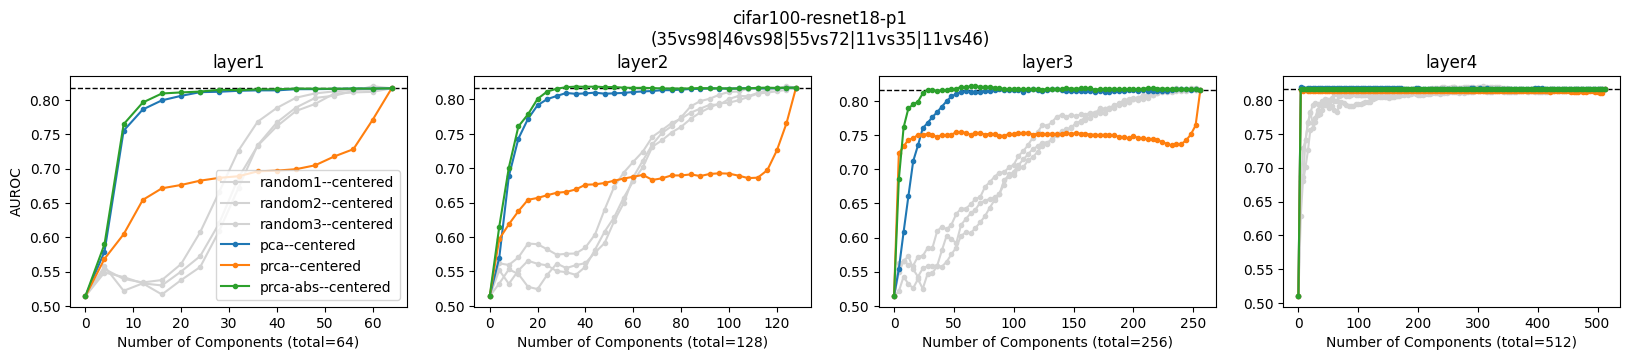

In [38]:
def color(name):
    if "random" in name:
        return 'lightgray'
    else:
        return None
    
def viz(
    class_pairs,
    model="cifar100-resnet18-p1",
    layers=["layer1", "layer2", "layer3", "layer4"],
    basis_mode="centered"
):
    
    ncols = len(layers)
    
    plt.figure(figsize=(ncols*5, 3))

    plt.suptitle("\n".join(
        [
            model, 
            "(%s)" % "|".join(map(lambda s: s.replace("cifar100-", ""), class_pairs))
        ]),
        y=1.1
    )
    basis_names = list(
        map(
            lambda s: f"{s}--{basis_mode}",
            [
                "random1", "random2", "random3",
                "pca", "prca", "prca-abs"
            ]
        )
    )
    
    for lix, layer in enumerate(layers):
                
        arr_ks = load_stats(class_pairs[0], model, layer, basis_names[0])["arr_ks"]
                
        original_auroc_corrected = []
    
        stat_layer_aurocs = np.zeros((len(class_pairs), len(basis_names), len(arr_ks)))
        
        for pix, pair in enumerate(class_pairs):

            ref_stats = load_stats(pair, model, layer, basis_names[0])
            original_auroc_corrected.append(ref_stats["original_auroc_corrected"])
            for bix, basis_name in enumerate(basis_names):

                stats = load_stats(pair, model, layer, basis_name)

                for k in ["arr_ks", "original_auroc_corrected"]:
                    np.testing.assert_allclose(ref_stats[k], stats[k], err_msg=f"key={k}")
                    
                    
                stat_layer_aurocs[pix, bix, :] = stats["arr_auroc_corrected"]
        
        
        plt.subplot(1, ncols, lix+1)
        plt.title(layer)
        plt.xlabel(f"Number of Components (total={arr_ks[-1]})")
     
    
        plt.axhline(np.mean(original_auroc_corrected), ls="--", lw=1, color="k")
        for bix, basis_name in enumerate(basis_names):
            plt.plot(
                arr_ks,
                np.mean(stat_layer_aurocs[:, bix, :], axis=0),
                label=basis_name,
                color=color(basis_name),
                marker="."
            )
            
            
        if lix == 0:
            plt.ylabel("AUROC")
            plt.legend()

viz(difficult_pairs)

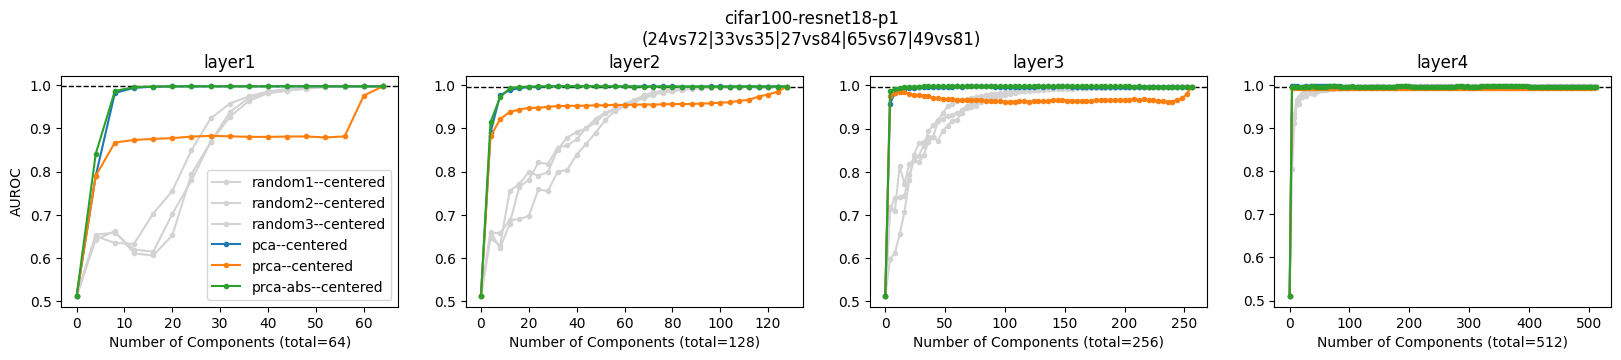

In [39]:
viz(random_pairs)

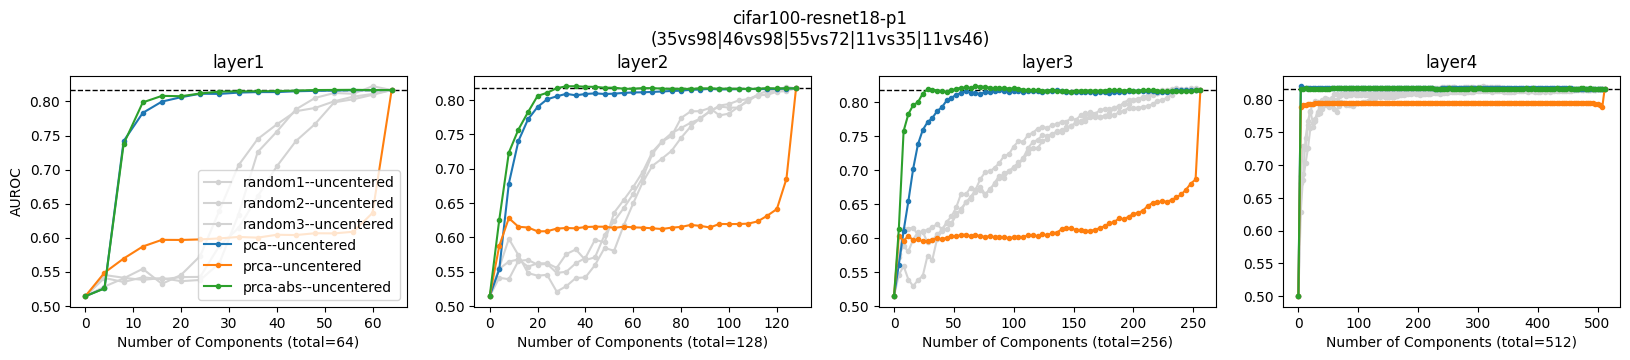

In [36]:
viz(difficult_pairs, basis_mode="uncentered")

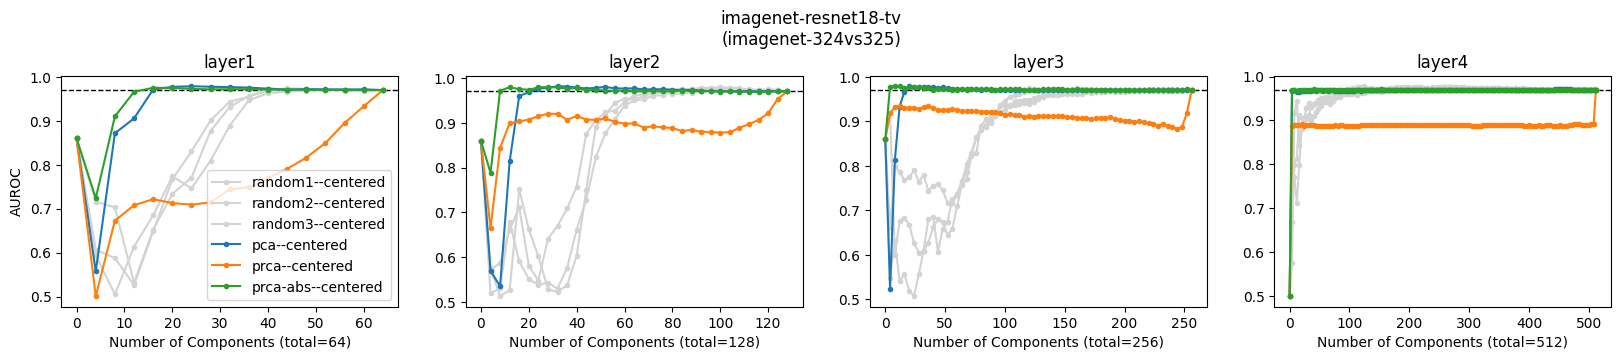

In [18]:
viz(
    ["imagenet-324vs325"],
    model="imagenet-resnet18-tv",
)

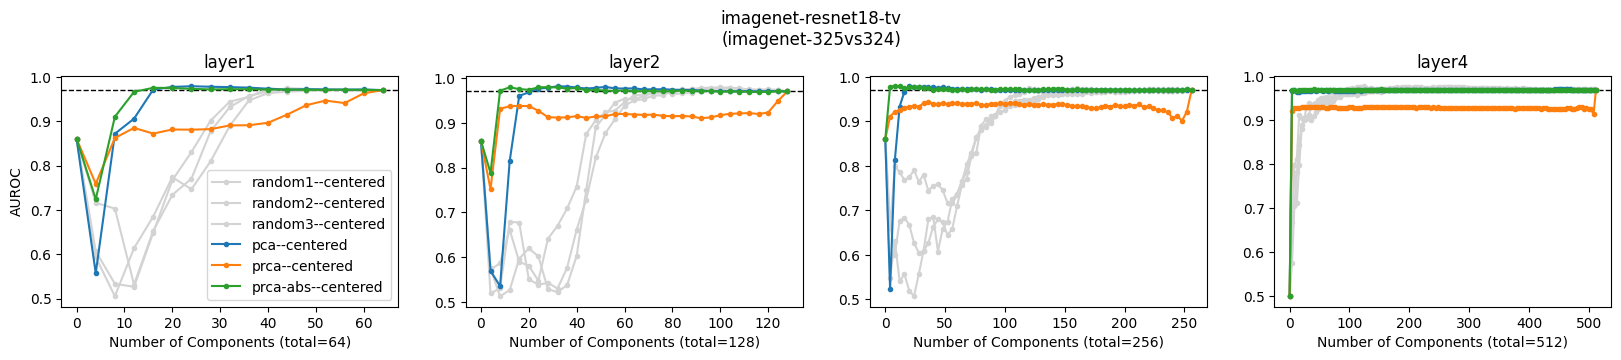

In [34]:
viz(
    ["imagenet-325vs324"],
    model="imagenet-resnet18-tv",
)

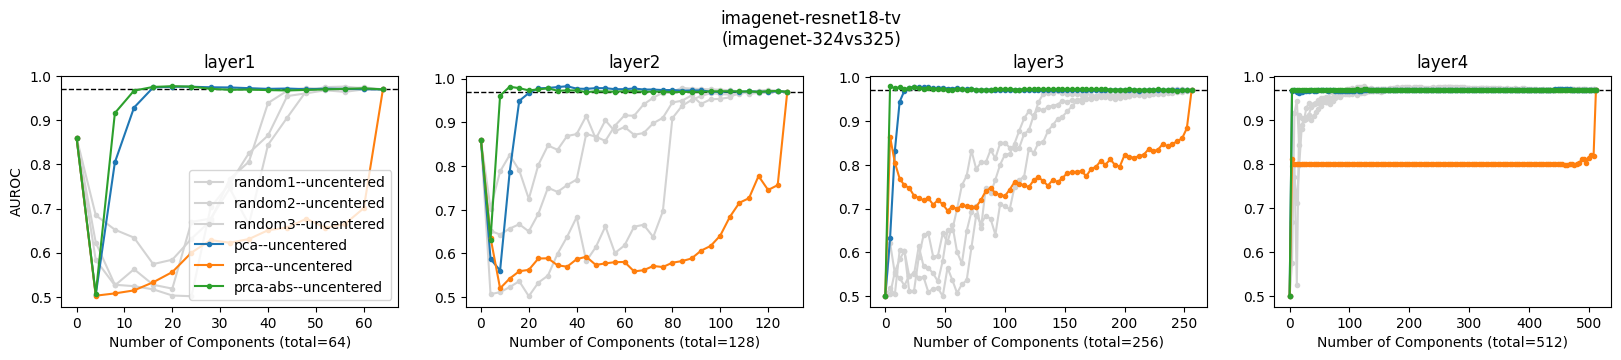

In [32]:
viz(
    ["imagenet-324vs325"],
    model="imagenet-resnet18-tv",
    basis_mode="uncentered"
)

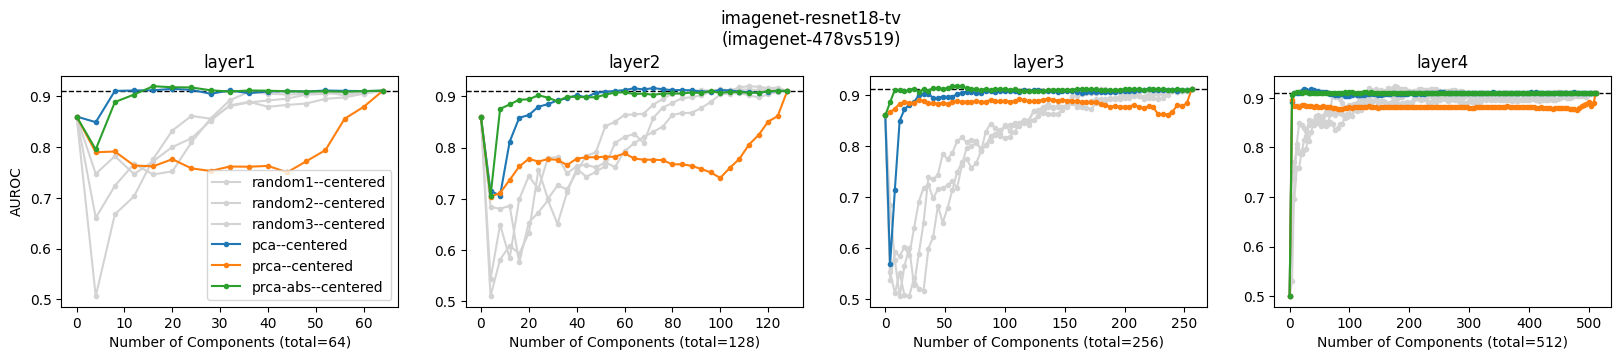

In [19]:
viz(
    ["imagenet-478vs519"],
    model="imagenet-resnet18-tv",
)

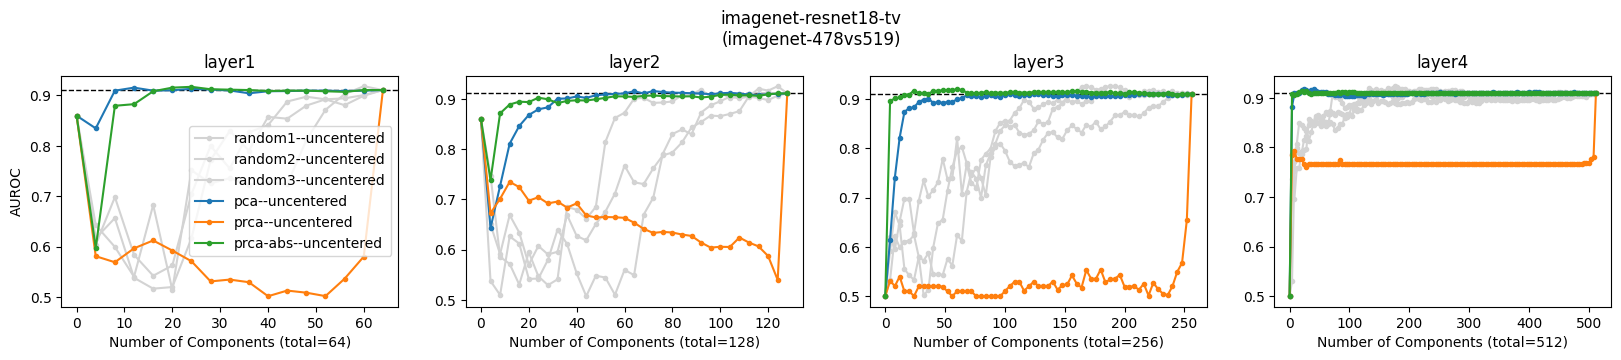

In [30]:
viz(
    ["imagenet-478vs519"],
    model="imagenet-resnet18-tv",
    basis_mode="uncentered"
)

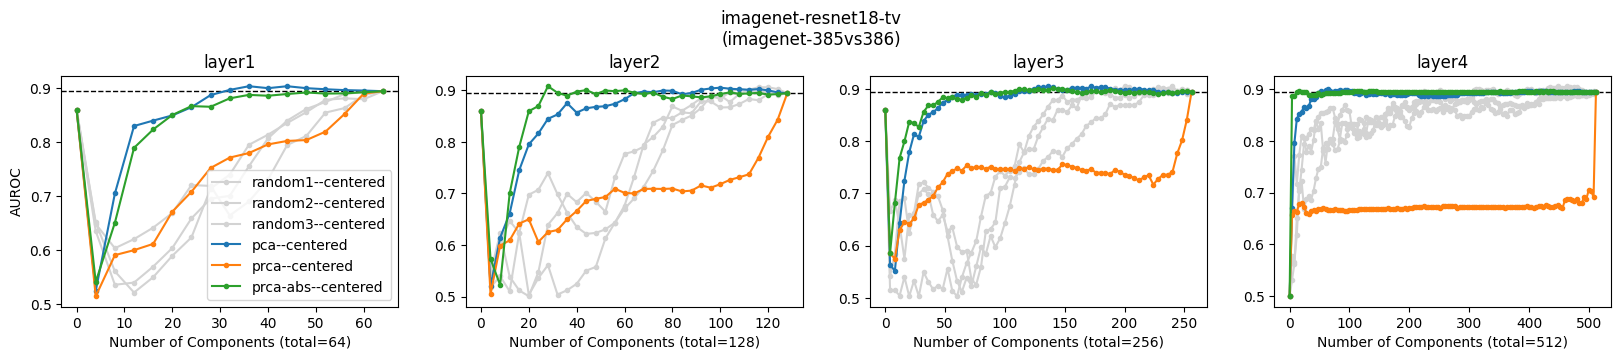

In [28]:
viz(
    ["imagenet-385vs386"],
    model="imagenet-resnet18-tv",
)

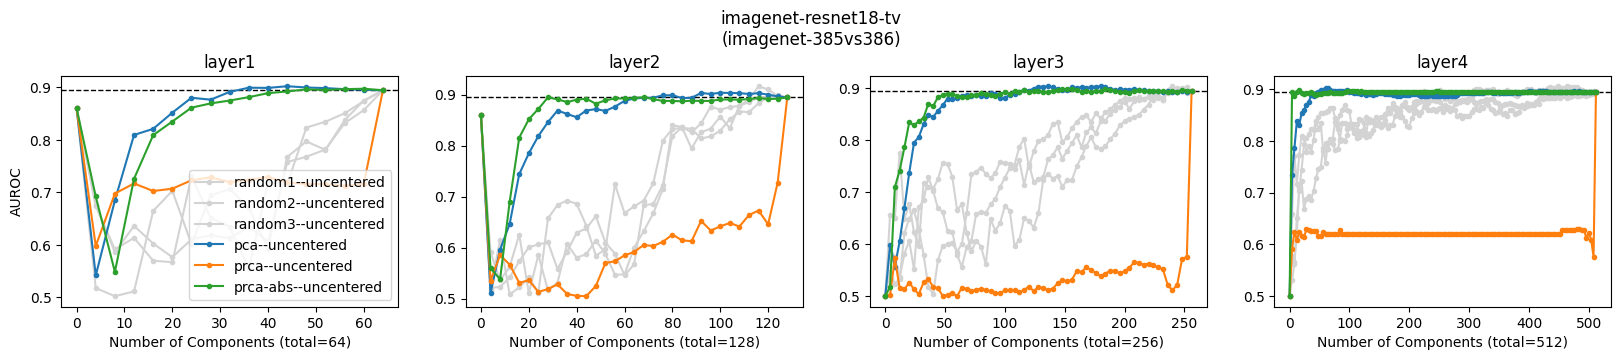

In [29]:
viz(
    ["imagenet-385vs386"],
    model="imagenet-resnet18-tv",
    basis_mode="uncentered"
)

In [26]:
print("END!")

END!
